2026-01-07 11-00-05
Outputs will be written to: results/run_2026-01-07 11-00-05
Saved a copy of the config : results/run_2026-01-07 11-00-05/config_copy.yaml
Inputs shape: (20, 2)
Outputs shape: (20,)
First 20 rows of raw data:
    number-1  number-2  log-likelyhood-score   source
9   0.702637  0.926564              0.611205     file
17  0.715000  0.950000              0.597629   week-8
13  0.691873  0.263356              0.596081   week-4
18  0.720000  0.950000              0.565857   week-9
0   0.665800  0.123969              0.538996     file
12  0.722766  0.839711              0.533827   week-3
19  0.658567  0.384858              0.490274  week-10
1   0.877791  0.778628              0.420586     file
3   0.845275  0.711120              0.293993     file
6   0.438166  0.685018              0.244619     file
4   0.454647  0.290455              0.214965     file
11  0.616162  1.000000              0.180119   week-2
10  0.818182  0.939394              0.051646   week-1
16  1.077791  0.

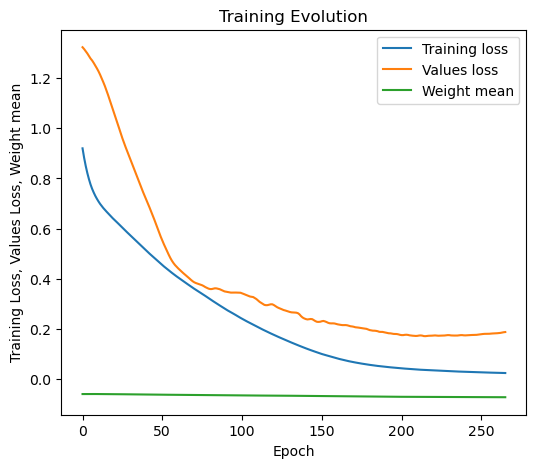

Using 2 dimensions, grid size per axis: 800, downsample: False, stride: 1
Points before downsampling: 640000
Points after downsampling: 640000
Final grid shape: (640000, 2)
sample_strategy=cartesian, Final sample shape: (640000, 2)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.68198739, 0.38242804]), 'score': 0.9995760574949768, 'dim': 2, 'predicted_y': 0.6545139}
{'method': 'PI', 'xi': 0.2, 'kappa': None, 'x': array([0.72460661, 0.56795995]), 'score': 0.6831027426685435, 'dim': 2, 'predicted_y': 0.68134576}
{'method': 'PI', 'xi': 0.5, 'kappa': None, 'x': array([0.72460661, 0.56386733]), 'score': 0.13404234116073827, 'dim': 2, 'predicted_y': 0.68133646}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.72460661, 0.56386733]), 'score': 0.20521402102598968, 'dim': 2, 'predicted_y': 0.68133646}
{'method': 'EI', 'xi': 0.2, 'kappa': None, 'x': array([0.72460661, 0.56386733]), 'score': 0.1287090

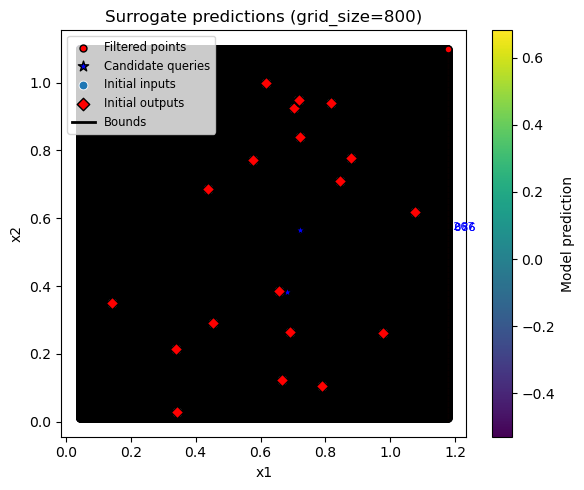

Saved dataframe to: results/run_2026-01-07 11-00-05/df_grid_800_stride1_None_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.72176533, 0.56523154]), 'score': 2.267184858035005, 'dim': 2, 'predicted_y': 0.6809139}
    number-1  number-2  log-likelyhood-score   source  log-likelyhood-score-scaled
0   0.721765  0.565232              2.267185   week-x                    10.000000
1   0.724607  0.563867              2.076312   week-x                     9.158107
2   0.724607  0.563867              1.885933   week-x                     8.318389
3   0.681987  0.382428              0.999576   week-x                     4.408886
4   0.724607  0.567960              0.683103   week-x                     3.013000
5   0.702637  0.926564              0.611205     file                     2.695877
6   0.715000  0.950000              0.597629   week-8                     2.635998
7   0.691873  0.263356              0.596081   week-4                  

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))